# Who breathes it in — Snohomish County environmental burden

Score-not-audio series companion, different medium: instead of a musical score, the data here is Washington State DOH's **Environmental Health Disparities (EHD) Map v3** — a live, official, tract-level dataset. Source: public ArcGIS FeatureServer, `Full_Extract_Environmental_Health_Disparities_Map_Version3`.

No single environmental indicator map shows where burden actually concentrates — that only shows up when the layers are stacked. Panel A shows four individual indicators for Snohomish County on their own (each looks scattered, moderate). Panel B shows DOH's own precomputed `Environmental_Exposures_Theme` composite — their real combination of these layers, not a formula invented here.

In [1]:
import json
from pathlib import Path

import requests
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_PATH = DATA_DIR / "wa_ehd_snohomish.geojson"

FEATURE_SERVER = (
    "https://services8.arcgis.com/rGGrs6HCnw87OFOT/arcgis/rest/services/"
    "Full_Extract_Environmental_Health_Disparities_Map_Version3/FeatureServer/0/query"
)
FIELDS = [
    "CensusTract2020",
    "PM2_5_Rank",
    "Diesel_AirToxics_Rank",
    "Heavy_Traffic_Roadways_Rank",
    "Wildfire_Smoke_Rank",
    "Environmental_Exposures_Theme",
]

# Snohomish County FIPS = 53061; CensusTract2020 encodes it as the leading 5 digits.
if CACHE_PATH.exists():
    geojson = json.loads(CACHE_PATH.read_text())
else:
    params = {
        "where": "CensusTract2020 >= 53061000000 AND CensusTract2020 < 53062000000",
        "outFields": ",".join(FIELDS),
        "returnGeometry": "true",
        "f": "geojson",
    }
    resp = requests.get(FEATURE_SERVER, params=params, timeout=30)
    resp.raise_for_status()
    geojson = resp.json()
    CACHE_PATH.write_text(json.dumps(geojson))

features = geojson["features"]
print(f"loaded {len(features)} Snohomish County tracts")

loaded 173 Snohomish County tracts


In [2]:
def tract_rings(geometry):
    """Yield exterior-ring (lon, lat) arrays for a Polygon or MultiPolygon feature.
    Interior holes ignored — irrelevant for a filled choropleth."""
    coords = geometry["coordinates"]
    polys = [coords] if geometry["type"] == "Polygon" else coords
    for poly in polys:
        yield np.array(poly[0])


# Longitude degrees compress relative to latitude away from the equator;
# correct the axes aspect ratio using this county's actual mean latitude
# instead of hardcoding a projection.
all_lats = np.concatenate(
    [ring[:, 1] for feat in features for ring in tract_rings(feat["geometry"])]
)
LAT_ASPECT = 1 / np.cos(np.radians(all_lats.mean()))


def plot_choropleth(ax, field, cmap="YlOrRd", vmin=1, vmax=10, title=""):
    patches, values = [], []
    for feat in features:
        val = feat["properties"][field]
        for ring in tract_rings(feat["geometry"]):
            patches.append(Polygon(ring, closed=True))
            values.append(val)
    coll = PatchCollection(patches, cmap=cmap)
    coll.set_array(np.array(values))
    coll.set_clim(vmin, vmax)
    coll.set_edgecolor("white")
    coll.set_linewidth(0.2)
    ax.add_collection(coll)
    ax.autoscale_view()
    ax.set_aspect(LAT_ASPECT)
    ax.axis("off")
    ax.set_title(title, fontsize=11)
    return coll

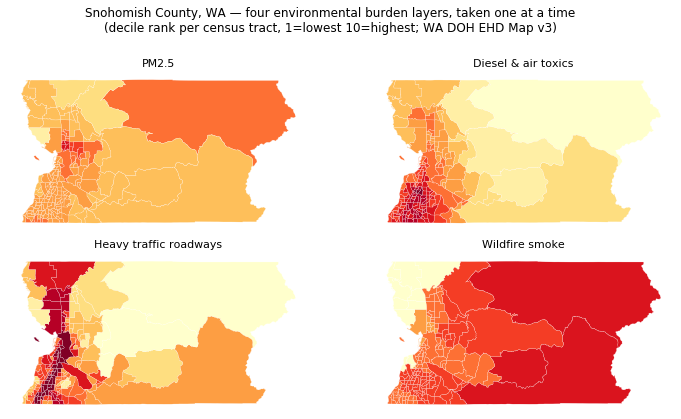

In [3]:
indicator_titles = {
    "PM2_5_Rank": "PM2.5",
    "Diesel_AirToxics_Rank": "Diesel & air toxics",
    "Heavy_Traffic_Roadways_Rank": "Heavy traffic roadways",
    "Wildfire_Smoke_Rank": "Wildfire smoke",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
for ax, (field, title) in zip(axes.flat, indicator_titles.items()):
    plot_choropleth(ax, field, title=title)
fig.suptitle(
    "Snohomish County, WA — four environmental burden layers, taken one at a time\n"
    "(decile rank per census tract, 1=lowest 10=highest; WA DOH EHD Map v3)",
    fontsize=12,
    y=0.99,
)
fig.subplots_adjust(top=0.85, hspace=0.15)
fig.savefig("envburden_snohomish_layers.png", dpi=150, bbox_inches="tight")
plt.show()

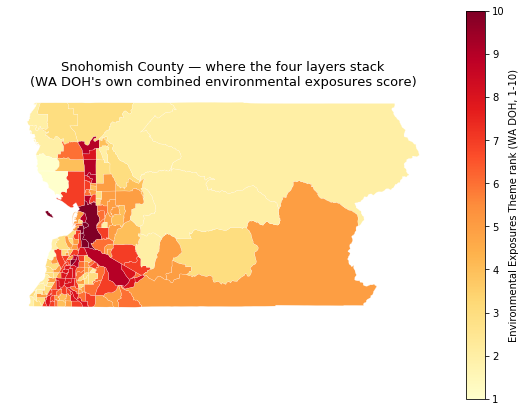

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
coll = plot_choropleth(ax, "Environmental_Exposures_Theme")
cbar = fig.colorbar(coll, ax=ax, shrink=0.7)
cbar.set_label("Environmental Exposures Theme rank (WA DOH, 1-10)")
ax.set_title(
    "Snohomish County — where the four layers stack\n"
    "(WA DOH's own combined environmental exposures score)",
    fontsize=13,
)
fig.tight_layout()
fig.savefig("envburden_snohomish.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Self-check: guards against silently pulling the wrong county or a broken field.
assert 150 < len(features) < 200, f"unexpected tract count: {len(features)}"
assert all(
    str(int(f["properties"]["CensusTract2020"])).startswith("53061")
    for f in features
), "non-Snohomish tract in result set"
assert all(
    f["properties"]["Environmental_Exposures_Theme"] is not None for f in features
), "missing composite score for a tract"
print("self-checks passed")

self-checks passed


## Panel C — which hazard actually sets the worst score, tract by tract

Panel B's composite doesn't say *why* a tract scores the way it does — Day 4's own analysis showed traffic is doing most of the work county-wide, but that's an average across 173 tracts, not a per-tract answer. For each tract, find the single hazard with the highest rank. If one hazard clearly wins, color the tract by which one. If two or more tie for the max (common on a 1-10 integer scale) or PM2.5 wins (never the county's worst layer, so treat it as noise here), call it "mixed" — no single hazard dominates that tract.

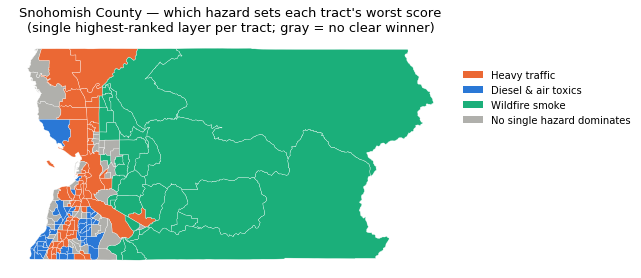

dominant-hazard self-check passed: {'diesel': 46, 'mixed': 41, 'traffic': 56, 'smoke': 30}


In [6]:
from collections import Counter
from matplotlib.patches import Patch

LAYER_NAMES = ["pm25", "diesel", "traffic", "smoke"]
LAYER_FIELDS = {
    "pm25": "PM2_5_Rank",
    "diesel": "Diesel_AirToxics_Rank",
    "traffic": "Heavy_Traffic_Roadways_Rank",
    "smoke": "Wildfire_Smoke_Rank",
}
# Validated 3-slot categorical palette (dataviz skill: 4th slot fails the
# all-pairs CVD floor on a choropleth, so PM2.5 folds into "mixed" instead
# of taking its own hue).
CATEGORY_COLORS = {
    "traffic": "#eb6834",
    "diesel": "#2a78d6",
    "smoke": "#1baf7a",
    "mixed": "#b0b0ac",
}
CATEGORY_LABELS = {
    "traffic": "Heavy traffic",
    "diesel": "Diesel & air toxics",
    "smoke": "Wildfire smoke",
    "mixed": "No single hazard dominates",
}
CATEGORY_ORDER = ["traffic", "diesel", "smoke", "mixed"]


def dominant_category(props):
    vals = {name: props[field] for name, field in LAYER_FIELDS.items()}
    maxval = max(vals.values())
    winners = [name for name, v in vals.items() if v == maxval]
    if len(winners) == 1 and winners[0] != "pm25":
        return winners[0]
    return "mixed"


fig, ax = plt.subplots(figsize=(8, 8))
patches, colors = [], []
for feat in features:
    cat = dominant_category(feat["properties"])
    for ring in tract_rings(feat["geometry"]):
        patches.append(Polygon(ring, closed=True))
        colors.append(CATEGORY_COLORS[cat])
coll = PatchCollection(patches, facecolor=colors, edgecolor="white", linewidth=0.3)
ax.add_collection(coll)
ax.autoscale_view()
ax.set_aspect(LAT_ASPECT)
ax.axis("off")
ax.set_title(
    "Snohomish County — which hazard sets each tract's worst score\n"
    "(single highest-ranked layer per tract; gray = no clear winner)",
    fontsize=13,
)
handles = [Patch(facecolor=CATEGORY_COLORS[c], label=CATEGORY_LABELS[c]) for c in CATEGORY_ORDER]
# Legend placed outside the axes entirely -- the densest, most interesting
# tracts (urban I-5 corridor) sit in the lower-left of this county's shape,
# exactly where an in-plot legend would otherwise land.
ax.legend(
    handles=handles, loc="upper left", bbox_to_anchor=(1.0, 0.9),
    frameon=False, fontsize=10,
)
fig.savefig("envburden_snohomish_dominant.png", dpi=150, bbox_inches="tight")
plt.show()

# Self-check: catches a broken dominant_category rule or a bad tract count silently.
counts = Counter(dominant_category(f["properties"]) for f in features)
assert sum(counts.values()) == len(features), "category counts don't cover all tracts"
assert set(counts) <= set(CATEGORY_ORDER), f"unexpected category: {set(counts) - set(CATEGORY_ORDER)}"
assert counts["traffic"] > counts["diesel"] > counts["smoke"], "expected traffic > diesel > smoke by tract count"
print("dominant-hazard self-check passed:", dict(counts))

## Panel D — population density, for reference

Does traffic/diesel dominance just track where people live? Population comes from Day 2's block-group data (snotrac, same GEOID-prefix aggregation used in `transit_pollution_overlap.ipynb` — no new pipeline), area from the tract polygons already loaded above via a local-degrees-to-km² approximation (no GDAL). Checked before writing the caption: traffic- and diesel-dominant tracts run 9-11x denser than smoke-dominant ones, but density only weakly predicts the *overall* composite score (Spearman rho~0.17, p~0.03) — density explains which hazard wins, not how bad the total burden gets.

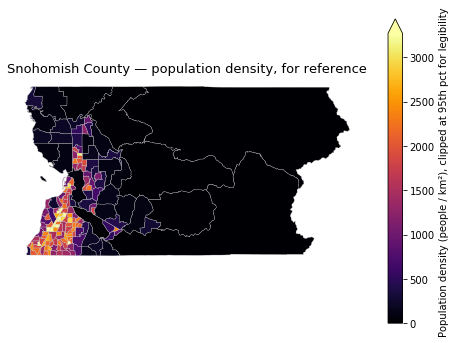

median density by dominant hazard: {'diesel': 2118.7, 'mixed': 1391.2, 'traffic': 1674.0, 'smoke': 186.8}
density vs composite score: spearman rho=0.169 (p=0.0267) -- weak, not the main story
self-check passed


In [11]:
from collections import defaultdict
from matplotlib.colors import Normalize
from scipy import stats

SNOTRAC_GEOJSON = Path("../snotrac/web/snohomish/data.geojson")
bg_features = json.loads(SNOTRAC_GEOJSON.read_text())["features"]

tract_pop = defaultdict(float)
for feat in bg_features:
    tract_id = int(feat["properties"]["GEOID"][:11])
    tract_pop[tract_id] += feat["properties"]["total_pop"] or 0


def tract_area_km2(geometry):
    """Shoelace formula on lon/lat degrees, locally corrected to km via this
    tract's own mean latitude. Not a true equal-area projection, but accurate
    enough at Snohomish County's scale (~1 degree of latitude span)."""
    coords = geometry["coordinates"]
    polys = [coords] if geometry["type"] == "Polygon" else coords
    total = 0.0
    for poly in polys:
        ring = np.array(poly[0])
        lat0 = ring[:, 1].mean()
        x = ring[:, 0] * 111.32 * np.cos(np.radians(lat0))
        y = ring[:, 1] * 110.57
        total += 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
    return total


patches, densities = [], []
tract_density = {}
for feat in features:
    tid = int(feat["properties"]["CensusTract2020"])
    area = tract_area_km2(feat["geometry"])
    dens = tract_pop[tid] / area if area > 0 else 0.0
    tract_density[tid] = dens
    for ring in tract_rings(feat["geometry"]):
        patches.append(Polygon(ring, closed=True))
        densities.append(dens)

fig, ax = plt.subplots(figsize=(8, 8))
coll = PatchCollection(patches, cmap="inferno")
coll.set_array(np.array(densities))
clip = np.percentile(densities, 95)
coll.set_norm(Normalize(vmin=0, vmax=clip))
# Light gray, not white -- a white-fill, white-edge tract in the sparse
# east would otherwise vanish into the page background.
coll.set_edgecolor("#c8c8c8")
coll.set_linewidth(0.3)
ax.add_collection(coll)
ax.autoscale_view()
ax.set_aspect(LAT_ASPECT)
ax.axis("off")
cbar = fig.colorbar(coll, ax=ax, shrink=0.7, extend="max")
cbar.set_label("Population density (people / km²), clipped at 95th pct for legibility")
ax.set_title("Snohomish County — population density, for reference", fontsize=13)
fig.savefig("envburden_snohomish_density.png", dpi=150, bbox_inches="tight")
plt.show()

# Self-check: verify the claim before it ships, not after.
assert set(int(f["properties"]["CensusTract2020"]) for f in features) <= set(tract_pop), (
    "envburden tract missing from population aggregation"
)
cat_density = defaultdict(list)
for f in features:
    tid = int(f["properties"]["CensusTract2020"])
    cat_density[dominant_category(f["properties"])].append(tract_density[tid])
medians = {c: np.median(v) for c, v in cat_density.items()}
print("median density by dominant hazard:", {c: round(m, 1) for c, m in medians.items()})
assert medians["traffic"] > 3 * medians["smoke"], "expected traffic tracts far denser than smoke tracts"
assert medians["diesel"] > 3 * medians["smoke"], "expected diesel tracts far denser than smoke tracts"

comp = np.array([f["properties"]["Environmental_Exposures_Theme"] for f in features])
dens_arr = np.array([tract_density[int(f["properties"]["CensusTract2020"])] for f in features])
rho, p = stats.spearmanr(dens_arr, comp)
print(f"density vs composite score: spearman rho={rho:.3f} (p={p:.4f}) -- weak, not the main story")
print("self-check passed")

## Source & caption notes

- Data: [WA DOH Environmental Health Disparities Map v3](https://doh.wa.gov/data-and-statistical-reports/washington-tracking-network-wtn/washington-environmental-health-disparities-map), queried live from its public ArcGIS FeatureServer.
- `Environmental_Exposures_Theme` is DOH's own precomputed composite of the individual indicators shown in Panel A — not a metric derived in this notebook.
- Every value here is a decile rank (1-10) relative to the rest of Washington State, not a raw pollution measurement.